# Phase 1 — Feature engineering

Issue [#15](https://github.com/vks-g/cmapss-rul-hybrid/issues/15). This notebook shows the effect of operating-regime normalization, examines causal sensor features against training RUL, and writes aligned FD001 feature matrices for downstream models. FD002 supplies the six-regime comparison; FD001 is the primary exported subset. Data files are local and never committed.

**Leakage boundary.** Exploratory plots use official training trajectories only. Final export fits sensor selection and regime statistics on all official training engines, then transforms official test engines with those statistics. For cross-validation, refit both on each training fold; do not reuse the final exported matrix to tune folds.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from rul.data.load import load_subset
from rul.features.regimes import RegimeNormalizer

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
DATA_DIR = REPO_ROOT / "data" / "raw" / "CMAPSSData"
SEED = 42
assert DATA_DIR.exists(), f"Place C-MAPSS files in {DATA_DIR}"


## 1. What six-regime normalization changes

FD002 has six operating conditions. We fit a six-cluster normalizer on its training rows and compare regime means for three representative sensors. To make raw sensors comparable on one color scale, the left plot first uses a *global* z-score for display only. The right plot uses the actual regime-fitted normalized values. This descriptive plot uses no test data and makes no claim about model accuracy.

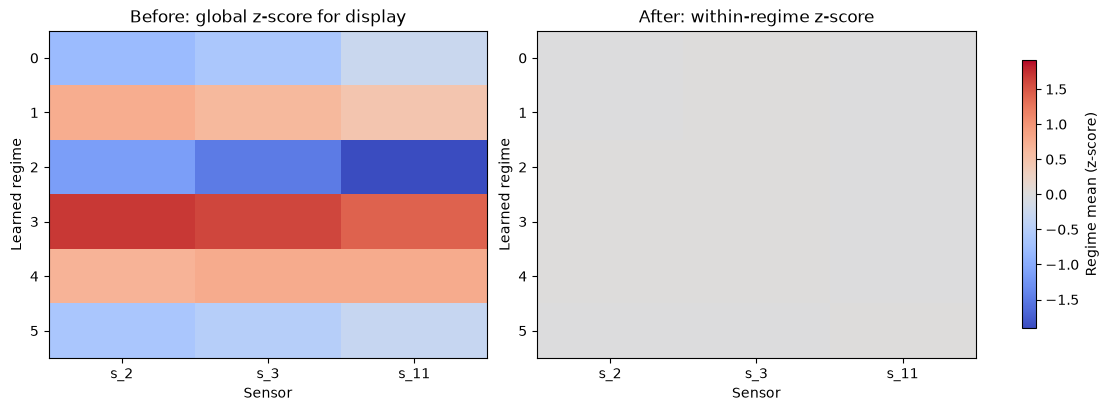

,before_global_z,after_regime_z
s_2,1.016594,1.964269e-13
s_3,1.031537,1.675449e-14
s_11,1.049667,8.973467e-15


In [2]:
fd002_train = load_subset("FD002", data_dir=DATA_DIR).train
fd002_normalizer = RegimeNormalizer(n_regimes=6, random_state=SEED).fit(fd002_train)
fd002_scaled = fd002_normalizer.transform(fd002_train)
plot_sensors = ["s_2", "s_3", "s_11"]
raw_global_z = (fd002_train[plot_sensors] - fd002_train[plot_sensors].mean()) / fd002_train[plot_sensors].std(ddof=0)
raw_regime_means = raw_global_z.groupby(fd002_scaled["regime"]).mean()
scaled_regime_means = fd002_scaled.groupby("regime")[plot_sensors].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
color_limit = max(1.0, np.abs(raw_regime_means.to_numpy()).max())
for ax, values, title in zip(
    axes,
    (raw_regime_means, scaled_regime_means),
    ("Before: global z-score for display", "After: within-regime z-score"),
):
    image = ax.imshow(values.to_numpy(), cmap="coolwarm", vmin=-color_limit, vmax=color_limit, aspect="auto")
    ax.set(xticks=range(len(plot_sensors)), xticklabels=plot_sensors,
           yticks=range(6), yticklabels=values.index, xlabel="Sensor", ylabel="Learned regime", title=title)
fig.colorbar(image, ax=axes, label="Regime mean (z-score)", shrink=0.82)
plt.show()

mean_dispersion = pd.DataFrame({
    "before_global_z": raw_regime_means.std(ddof=0),
    "after_regime_z": scaled_regime_means.std(ddof=0),
})
display(mean_dispersion)
assert np.abs(scaled_regime_means.to_numpy()).max() < 1e-10


The three sensors' regime-mean dispersion is about **one global standard deviation before normalization** and effectively zero afterward (the residual is floating-point rounding). This confirms removal of between-regime mean offsets in the training rows; it does not show improved RUL prediction by itself.